In [60]:
import pandas as pd
import numpy as np
import glob as glob
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import re
import duckdb
# from joblib import Parallel, delayed

# Loading in chunks

In [61]:
chunk_umi_count_paths = glob.glob("../../output/NKX2-2/downsampling/*RTBC*/*reads_per_umi.tsv")
len(chunk_umi_count_paths)

59

In [62]:
con = duckdb.connect(database=":memory:")

results = []

for path in tqdm(chunk_umi_count_paths):
    try:
        n = con.execute(
            """
            SELECT COUNT(DISTINCT UMI)
            FROM read_csv(
                ?,
                delim='\t',
                header=true,
                auto_detect=false,
                columns={
                    'RPTR_BC': 'VARCHAR',
                    'UMI': 'VARCHAR',
                    'reads': 'INTEGER'
                }
            )
            """,
            [path],
        ).fetchone()[0]

        results.append({"path": path, "unique_umis": n})

    except Exception as e:
        results.append({"path": path, "unique_umis": None, "error": str(e)})

df = pd.DataFrame(results)
df

100%|██████████| 59/59 [00:05<00:00,  9.98it/s]


,path,unique_umis
0,../../output/NKX2-2/downsampling/trebl_experim...,262008
1,../../output/NKX2-2/downsampling/trebl_experim...,558626
2,../../output/NKX2-2/downsampling/trebl_experim...,164070
3,../../output/NKX2-2/downsampling/trebl_experim...,1519010
4,../../output/NKX2-2/downsampling/trebl_experim...,93172
5,../../output/NKX2-2/downsampling/trebl_experim...,1068159
6,../../output/NKX2-2/downsampling/trebl_experim...,559347
7,../../output/NKX2-2/downsampling/trebl_experim...,296482
8,../../output/NKX2-2/downsampling/trebl_experim...,1693252
9,../../output/NKX2-2/downsampling/trebl_experim...,928985


In [63]:
df['num_splits'] = df['path'].str.extract(r'_(\d+)_chunks').astype(int)
df

,path,unique_umis,num_splits
0,../../output/NKX2-2/downsampling/trebl_experim...,262008,5
1,../../output/NKX2-2/downsampling/trebl_experim...,558626,20
2,../../output/NKX2-2/downsampling/trebl_experim...,164070,10
3,../../output/NKX2-2/downsampling/trebl_experim...,1519010,4
4,../../output/NKX2-2/downsampling/trebl_experim...,93172,20
5,../../output/NKX2-2/downsampling/trebl_experim...,1068159,8
6,../../output/NKX2-2/downsampling/trebl_experim...,559347,20
7,../../output/NKX2-2/downsampling/trebl_experim...,296482,4
8,../../output/NKX2-2/downsampling/trebl_experim...,1693252,3
9,../../output/NKX2-2/downsampling/trebl_experim...,928985,10


In [64]:
df[df["num_splits"] == 2]

,path,unique_umis,num_splits
24,../../output/NKX2-2/downsampling/trebl_experim...,1921004,2
27,../../output/NKX2-2/downsampling/trebl_experim...,401615,2
43,../../output/NKX2-2/downsampling/trebl_experim...,1920541,2
49,../../output/NKX2-2/downsampling/trebl_experim...,401869,2


In [65]:
df[df["num_splits"] == 2]["path"].iloc[-2]

'../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_fastq_2_chunks_part_1_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_2_chunks_part_1.fq_reads_per_umi.tsv'

In [66]:
df[df["num_splits"] == 2]["path"].iloc[-1]

'../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_2_chunks_part_2_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_2_chunks_part_2.fq_reads_per_umi.tsv'

In [67]:
df["num_splits"].value_counts()

num_splits
10    11
5     10
20    10
8     10
4      8
3      6
2      4
Name: count, dtype: int64

In [68]:
df["path"].iloc[0]

'../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_5_chunks_part_3_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_5_chunks_part_3.fq_reads_per_umi.tsv'

In [69]:
df["percent_reads"] = 100 / df["num_splits"]
df["time"] = df["path"].str.extract("_T(\d+)_S")
df

,path,unique_umis,num_splits,percent_reads,time
0,../../output/NKX2-2/downsampling/trebl_experim...,262008,5,20.000000,4
1,../../output/NKX2-2/downsampling/trebl_experim...,558626,20,5.000000,24
2,../../output/NKX2-2/downsampling/trebl_experim...,164070,10,10.000000,4
3,../../output/NKX2-2/downsampling/trebl_experim...,1519010,4,25.000000,24
4,../../output/NKX2-2/downsampling/trebl_experim...,93172,20,5.000000,4
5,../../output/NKX2-2/downsampling/trebl_experim...,1068159,8,12.500000,24
6,../../output/NKX2-2/downsampling/trebl_experim...,559347,20,5.000000,24
7,../../output/NKX2-2/downsampling/trebl_experim...,296482,4,25.000000,4
8,../../output/NKX2-2/downsampling/trebl_experim...,1693252,3,33.333333,24
9,../../output/NKX2-2/downsampling/trebl_experim...,928985,10,10.000000,24


# Getting unique UMIs at 75% and 100% from 25% splits

In [70]:
def umi_coverage_for_timepoint(tsv_paths, timepoint):
    records = []

    # ---- Read + dedupe per file ----
    for path in tqdm(tsv_paths, desc="Reading TSVs", unit="file"):
        path = Path(path)
        m = re.search(r"_part_(\d+)", path.name)
        if not m:
            continue

        part = int(m.group(1))
        chunk_id = re.sub(r"_part_\d+.*", "", path.name)

        df = pd.read_csv(
            path,
            sep="\t",
            usecols=["UMI"],
            dtype="string",
        ).drop_duplicates()

        df["chunk_id"] = chunk_id
        df["part"] = part
        records.append(df)

    big = pd.concat(records, ignore_index=True)

    # ---- Keep only complete 4-part chunks ----
    valid_chunks = big.groupby("chunk_id")["part"].nunique().eq(4)
    big = big[big["chunk_id"].map(valid_chunks)]

    # ---- Compute true unions for each chunk ----
    rows = []
    for chunk_id, g in tqdm(big.groupby("chunk_id"), desc="Counting UMIs", unit="chunk"):
        umis_parts = {p: set(sub["UMI"]) for p, sub in g.groupby("part")}
        
        rows.extend([
            {
                "unique_umis": len(umis_parts[1] | umis_parts[2] | umis_parts[3]),
                "num_splits": 100/75,
                "percent_reads": 75.0,
                "time": timepoint,
            },
            {
                "unique_umis": len(umis_parts[2] | umis_parts[3] | umis_parts[4]),
                "num_splits": 100/75,
                "percent_reads": 75.0,
                "time": timepoint,
            },
            {
                "unique_umis": len(umis_parts[1] | umis_parts[2] | umis_parts[3] | umis_parts[4]),
                "num_splits": 1,
                "percent_reads": 100.0,
                "time": timepoint,
            },
        ])

    return pd.DataFrame(rows)

In [71]:
chunk_umi_4_25_count_paths = glob.glob("../../output/NKX2-2/downsampling/*RTBC*/*T4*4_chunks_*reads_per_umi.tsv")
chunk_umi_4_25_count_paths

['../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_4_chunks_part_3_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_4_chunks_part_3.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_4_chunks_part_1_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_4_chunks_part_1.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_4_chunks_part_4_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_4_chunks_part_4.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_fastq_4_chunks_part_2_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_4_chunks_part_2.fq_reads_per_umi.tsv']

In [72]:
chunk_umi_24_25_count_paths = glob.glob("../../output/NKX2-2/downsampling/*RTBC*/*T24*4_chunks_*reads_per_umi.tsv")
chunk_umi_24_25_count_paths

['../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_fastq_4_chunks_part_2_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_4_chunks_part_2.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_fastq_4_chunks_part_4_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_4_chunks_part_4.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_fastq_4_chunks_part_3_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_4_chunks_part_3.fq_reads_per_umi.tsv',
 '../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_fastq_4_chunks_part_1_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_4_chunks_part_1.fq_reads_per_umi.tsv']

In [73]:
t4_75_100 = umi_coverage_for_timepoint(chunk_umi_4_25_count_paths, "4")
t4_75_100

Counting UMIs: 100%|██████████| 1/1 [00:01<00:00,  1.07s/chunk]


,unique_umis,num_splits,percent_reads,time
0,456366,1.333333,75.0,4
1,456829,1.333333,75.0,4
2,493965,1.000000,100.0,4


In [74]:
t24_75_100 = umi_coverage_for_timepoint(chunk_umi_24_25_count_paths, "24")
t24_75_100

Counting UMIs: 100%|██████████| 1/1 [00:06<00:00,  6.16s/chunk]


,unique_umis,num_splits,percent_reads,time
0,2132683,1.333333,75.0,24
1,2132912,1.333333,75.0,24
2,2287912,1.000000,100.0,24


# Unique curve

In [75]:
# Appending 75 and 100
df_with_all = pd.concat(
    [df, t4_75_100, t24_75_100],
    ignore_index=True
)
df_with_all = df_with_all.drop(columns = 'path')
df_with_all

,unique_umis,num_splits,percent_reads,time
0,262008,5.000000,20.0,4
1,558626,20.000000,5.0,24
2,164070,10.000000,10.0,4
3,1519010,4.000000,25.0,24
4,93172,20.000000,5.0,4
...,...,...,...,...
60,456829,1.333333,75.0,4
61,493965,1.000000,100.0,4
62,2132683,1.333333,75.0,24
63,2132912,1.333333,75.0,24


In [76]:
time_4_summary = df_with_all[df_with_all["time"] == "4"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
time_4_summary["percent_reads"] = time_4_summary["percent_reads"].astype(int)
time_4_summary

/tmp/ipykernel_1888610/549105974.py:1: FutureWarning: The provided callable <function mean at 0x1470f453fe20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  time_4_summary = df_with_all[df_with_all["time"] == "4"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_1888610/549105974.py:1: FutureWarning: The provided callable <function std at 0x1470f453ff60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  time_4_summary = df_with_all[df_with_all["time"] == "4"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()


num_splits percent_reads time    unique_umis            
                                          mean         std
0   1.000000           100    4  493965.000000         NaN
1   1.333333            75    4  456597.500000  327.390440
2   2.000000            50    4  401742.000000  179.605122
3   3.000000            33    4  341237.666667  100.729009
4   4.000000            25    4  296525.250000  234.894835
5   5.000000            20    4  261717.400000  176.186833
6   8.000000            12    4  192644.200000  173.951717
7  10.000000            10    4  163854.666667  115.319845
8  20.000000             5    4   93214.600000  105.516823

In [77]:
time_24_summary = df_with_all[df_with_all["time"] == "24"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
time_24_summary["percent_reads"] = time_24_summary["percent_reads"].astype(int)
time_24_summary

/tmp/ipykernel_1888610/3909791073.py:1: FutureWarning: The provided callable <function mean at 0x1470f453fe20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  time_24_summary = df_with_all[df_with_all["time"] == "24"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()
/tmp/ipykernel_1888610/3909791073.py:1: FutureWarning: The provided callable <function std at 0x1470f453ff60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  time_24_summary = df_with_all[df_with_all["time"] == "24"].groupby(["num_splits", "percent_reads", "time"]).agg([np.mean, np.std]).reset_index()


num_splits percent_reads time unique_umis            
                                       mean         std
0   1.000000           100   24   2287912.0         NaN
1   1.333333            75   24   2132797.5  161.927453
2   2.000000            50   24   1920772.5  327.390440
3   3.000000            33   24   1693688.0  632.958134
4   4.000000            25   24   1518651.0  572.527146
5   5.000000            20   24   1375312.6  705.398327
6   8.000000            12   24   1068587.0  643.666451
7  10.000000            10   24    928860.0  478.702935
8  20.000000             5   24    558901.8  382.884708

In [78]:
time_24_total_reads = 16320819
time_4_total_reads = 2976628

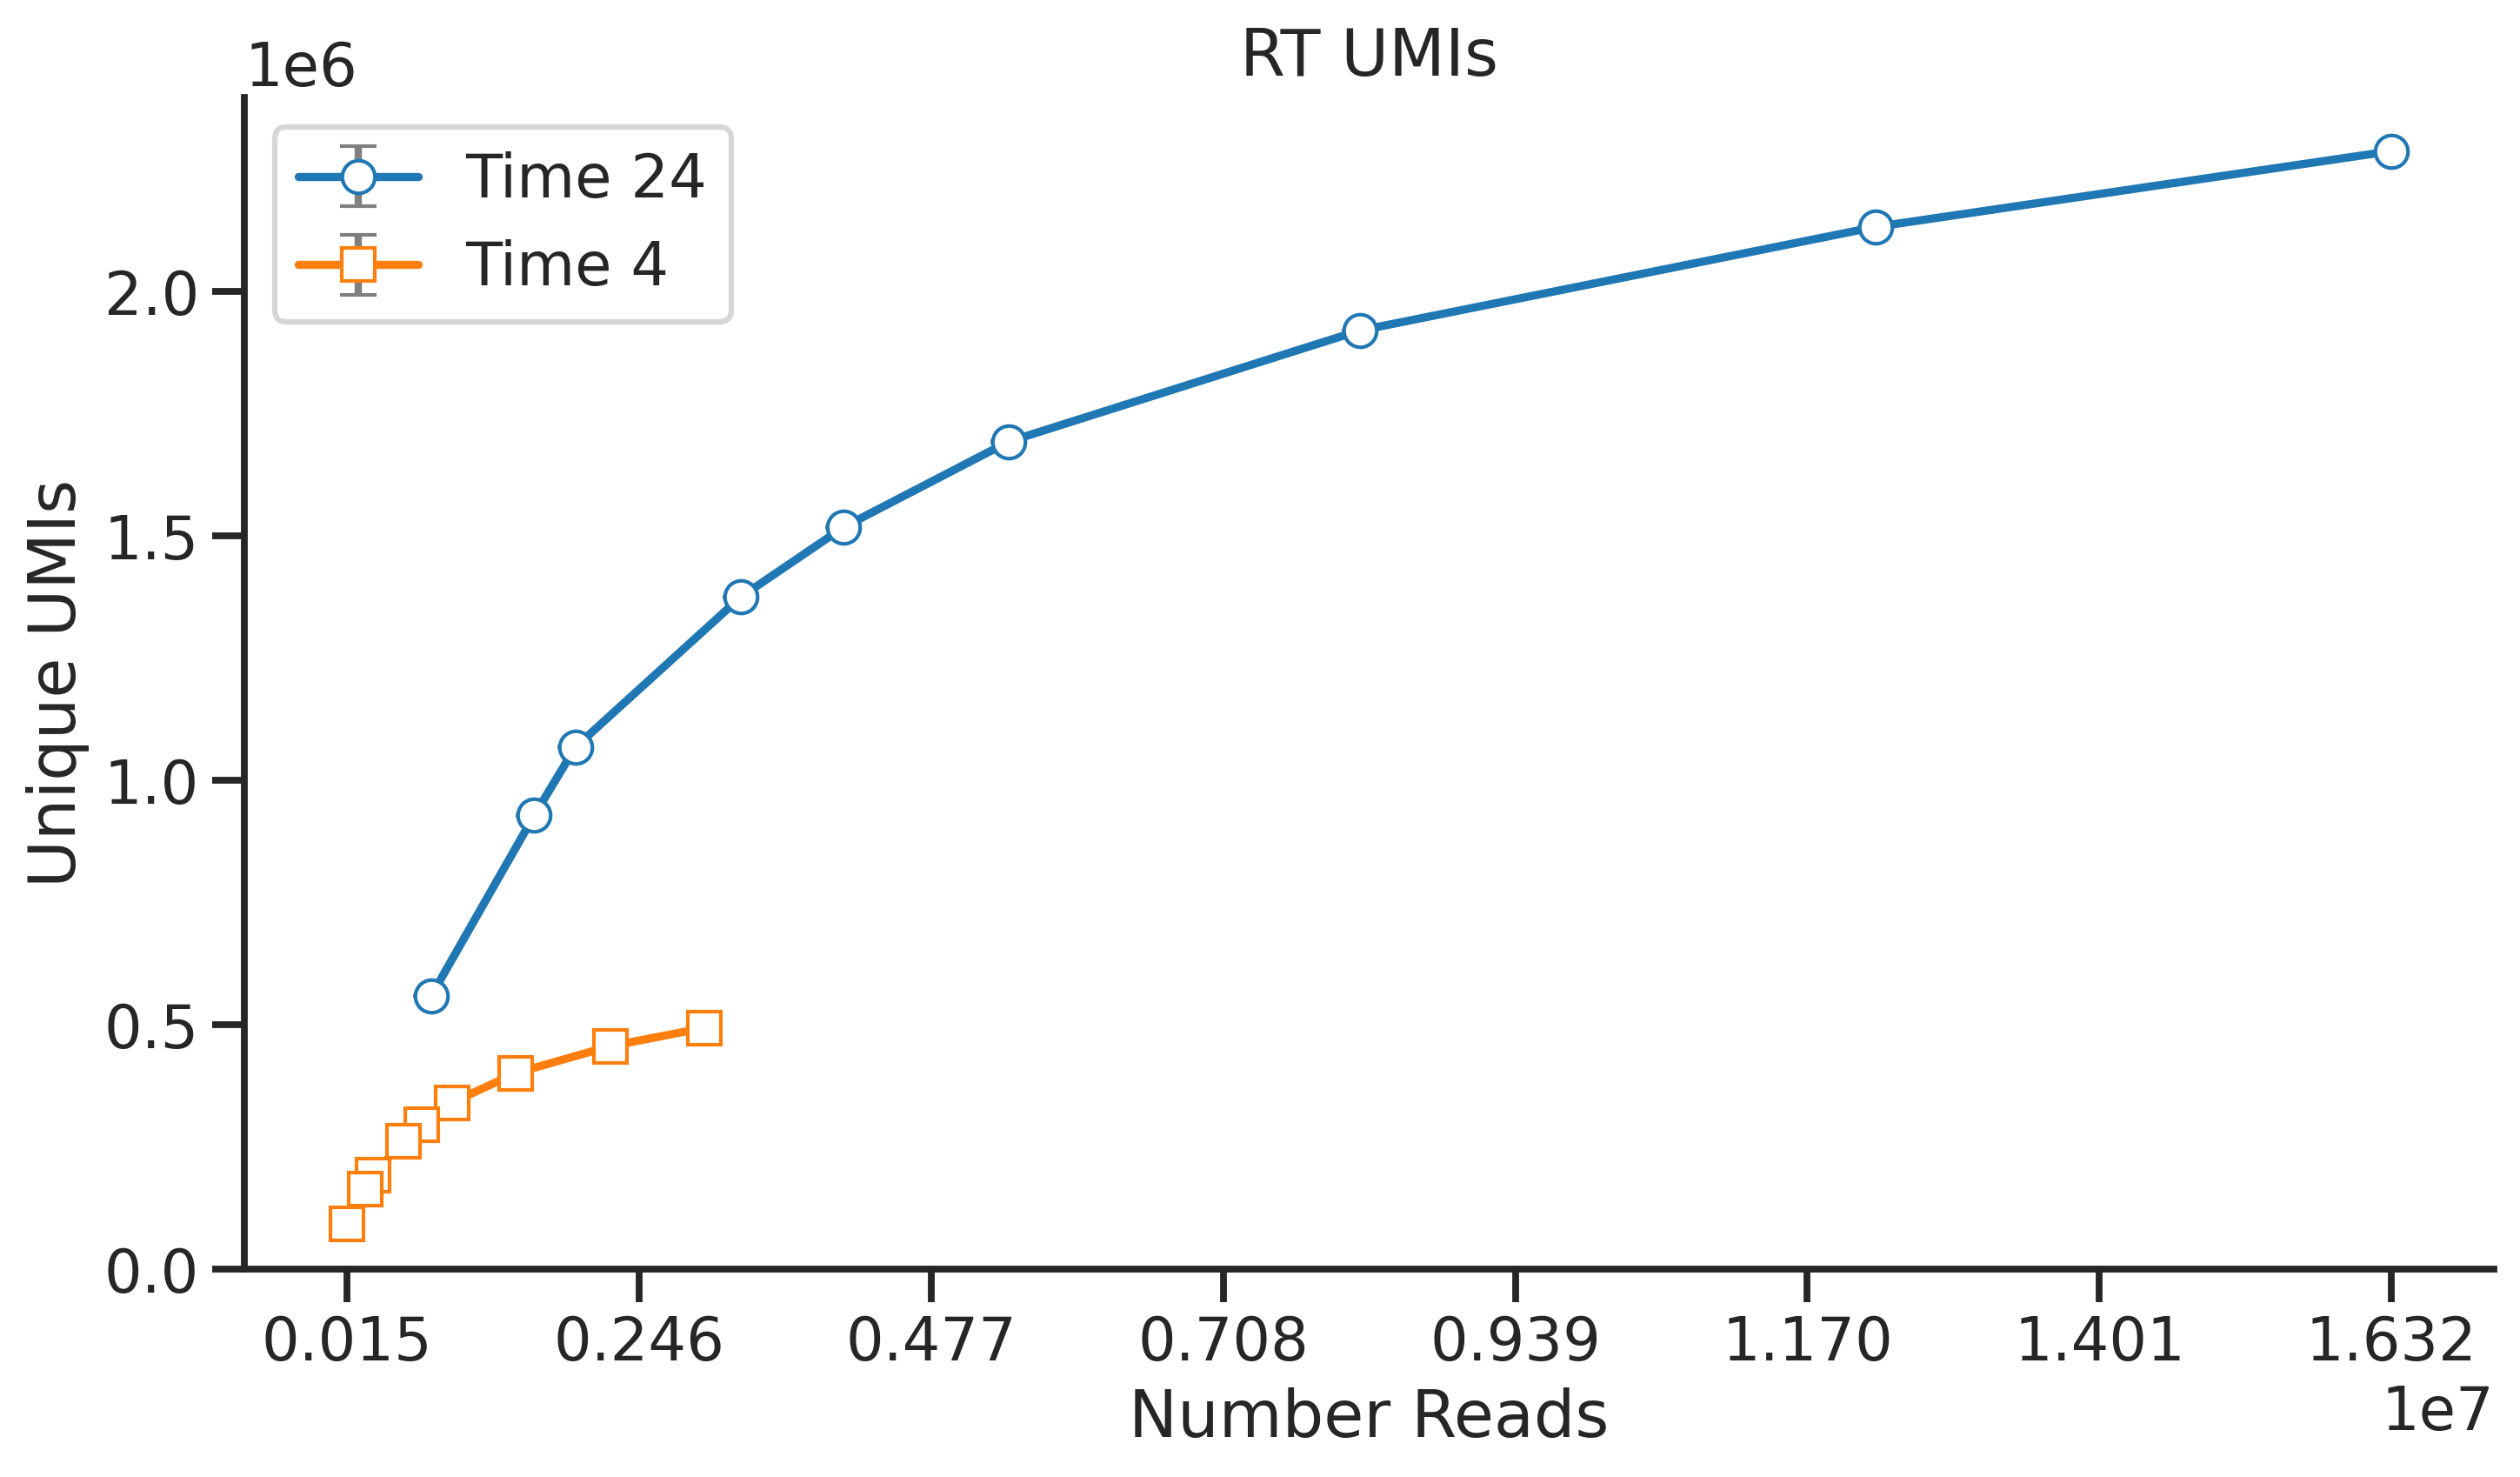

In [80]:
sns.set(style="ticks")
sns.set_context('talk')

plt.figure(figsize=(10,6), dpi=300)

# --- Time 30 ---
x_30 = time_24_summary['percent_reads'] * time_24_total_reads / 100
y_mean_30 = time_24_summary[('unique_umis', 'mean')]
y_std_30 = time_24_summary[('unique_umis', 'std')]

plt.errorbar(
    x=x_30,
    y=y_mean_30,
    yerr=y_std_30,
    fmt='-o',
    capsize=5,
    color='tab:blue',
    ecolor='tab:gray',
    elinewidth=2,
    markerfacecolor='white',
    label='Time 24'
)

# --- Time 5 ---
x_5 = time_4_summary['percent_reads'] * time_4_total_reads / 100
y_mean_5 = time_4_summary[('unique_umis', 'mean')]
y_std_5 = time_4_summary[('unique_umis', 'std')]

plt.errorbar(
    x=x_5,
    y=y_mean_5,
    yerr=y_std_5,
    fmt='-s',
    capsize=5,
    color='tab:orange',
    ecolor='tab:gray',
    elinewidth=2,
    markerfacecolor='white',
    label='Time 4'
)

# Labels, legend, title
plt.xlabel("Number Reads")
plt.ylabel("Unique UMIs")
plt.title("RT UMIs")

# --- Standard / more frequent x-ticks ---
all_x = np.concatenate([x_30, x_5])
plt.xticks(np.linspace(all_x.min(), all_x.max(), 8))  # 8 evenly spaced ticks

# plt.xlim(-10000000,)
plt.ylim(-1,)

plt.legend()
plt.tight_layout()
sns.despine()
plt.show()
